# 02 — Preprocessing

Margin removal, pad to square, resize, normalize. Then re-running the leakage
controls from notebook 01 on the cropped data to check whether cropping
actually removed the background shortcut.

**Order is important:** crop → pad → resize → normalize. 

From notebook 01:
- Sizes vary 150–1338px, ~20% non-square → pad, don't stretch
- Mixed channel modes (RGB / L / RGBA) → convert to `L` early
- Border-only classification hits 0.634 vs 0.262 baseline → cropping is
  leakage mitigation, and must be re-measured
- `notumor` is a different pulse sequence → cropping will NOT fix that

## 1. Setup

In [1]:
import csv, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

with open("data/manifest.csv") as f:
    rows = list(csv.DictReader(f))

records = [(r["split"], r["class"], Path(r["path"])) for r in rows]
CLASSES = sorted({r["class"] for r in rows})
SPLITS = ["Training", "Testing"]
meta = {p: (s, c) for s, c, p in records}

print(f"{len(records)} records, classes: {CLASSES}")

7200 records, classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. The crop function

Standard contour-based approach:

1. Blur to suppress noise that would fragment the threshold
2. Fixed threshold: using a low baseline value since MRI background is very low intensity anyway
3. Erode then dilate to remove speckle without shrinking the brain
4. Take the largest contour which is the head
5. Crop to its bounding box with a small padding margin

**Important:** this is not skull-stripping. In sagittal views the largest contour is
the entire head including face and neck. This removes black margins and
watermark bars, not non-brain tissue.

In [32]:
def crop_margins(img_gray, pad=4, thresh_val=35, debug=False):
    """
    Crop an MRI slice to the bounding box of the head, removing black margins
    and edge artifacts (watermark bars, padding, scanner borders).

    This is margin removal function. 

    Parameters
    ----------
    img_gray : 2-D uint8 array
        Single-channel image. Convert with .convert("L") before calling —
        the dataset mixes RGB, L and RGBA modes.
    pad : int
        Pixels of margin retained around the detected head. A few pixels of
        slack protects against the threshold clipping the skull edge.
    thresh_val : int
        Fixed intensity cutoff separating air from tissue.
    debug : bool
        If True, also return the binary mask so you can see what the
        threshold actually selected.

    Returns
    -------
    Cropped array, or (cropped, mask) when debug=True. Returns the ORIGINAL
    image unchanged if detection fails either safety check.
    """

    # --- 1. Blur -----------------------------------------------------------
    # Raw MRI carries fine acquisition noise. Without smoothing, the threshold
    # fragments into hundreds of speckle contours and "largest contour" (brain)
    # becomes unreliable. A 5x5 Gaussian is used to suppress noise without
    # blurring away the skull boundary needed for accurate cropping. 
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # --- 2. Threshold ------------------------------------------------------
    # FIXED threshold
    #
    # Otsu was used initially but it sometimes splits between BRAIN and LESION rather than between AIR and TISSUE 
    # and the crop lands on the tumor itself. That was seen on this dataset because a 236x236 glioma slice cropped 
    # to 153x69 containing only the enhancing mass.
    #
    # MRI background is near-zero regardless of how bright the tissue is, so
    # a low fixed cutoff is both simpler and more robust. Deliberately
    # permissive: we want the whole head, not the brightest structure in it.
    _, thresh = cv2.threshold(blurred, thresh_val, 255, cv2.THRESH_BINARY)

    # --- 3. Morphological cleanup ------------------------------------------
    # Erode removes isolated bright specks in the background that would otherwise register as contours.
    thresh = cv2.erode(thresh, None, iterations=2)

    # Dilate MORE than we eroded (4 vs 2). If the threshold fragmented the
    # head into separate blobs dilation reconnects them into one contour. The cost is a
    # slightly generous bounding box, which is fine as it is more conservative. 
    # over-cropping loses anatomy, under-cropping only leaves black margin.
    thresh = cv2.dilate(thresh, None, iterations=4) 

    # --- 4. Find the head --------------------------------------------------
    # RETR_EXTERNAL returns only outermost contours, ignoring holes inside the head (ventricles, sinuses) 
    # which we don't care about here.
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    # No contours at all means the image is essentially blank. Return unchanged rather than raising
    if not contours:
        return (img_gray, thresh) if debug else img_gray

    # Largest by area is the head. Smaller contours are watermark bars, burned-in text, or leftover noise
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    # --- 5. Apply padding, clipped to image bounds -------------------------
    # max/min prevent indexing outside the array when the head touches an edge.
    H, W = img_gray.shape
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(W, x + w + pad), min(H, y + h + pad)
    out = img_gray[y0:y1, x0:x1]

    # --- 6. Safety check: intensity mass -----------------------------------
    # Verifying the crop kept essentially all the image's brightness.
    #
    # A correct crop discards black margin, which contributes almost nothing 
    # to the total: so a good crop retains >99% of intensity even while
    # removing 50% of the pixels.
    #
    # max(..., 1) guards against division by zero on an all-black image.
    kept = out.astype(np.float64).sum() / max(img_gray.astype(np.float64).sum(), 1)
    if kept < 0.90:
        # Detection failed. Return the original — a black margin is a much
        # smaller problem than a silently mis-cropped image.
        return (img_gray, thresh) if debug else img_gray

    return (out, thresh) if debug else out

## 3. Validate it visually

Looking at real images before trusting the function on
7,200. Failure mode to watch for: a bright watermark bar or burned-in text
becoming the largest contour, so you crop to the annotation instead of the head.

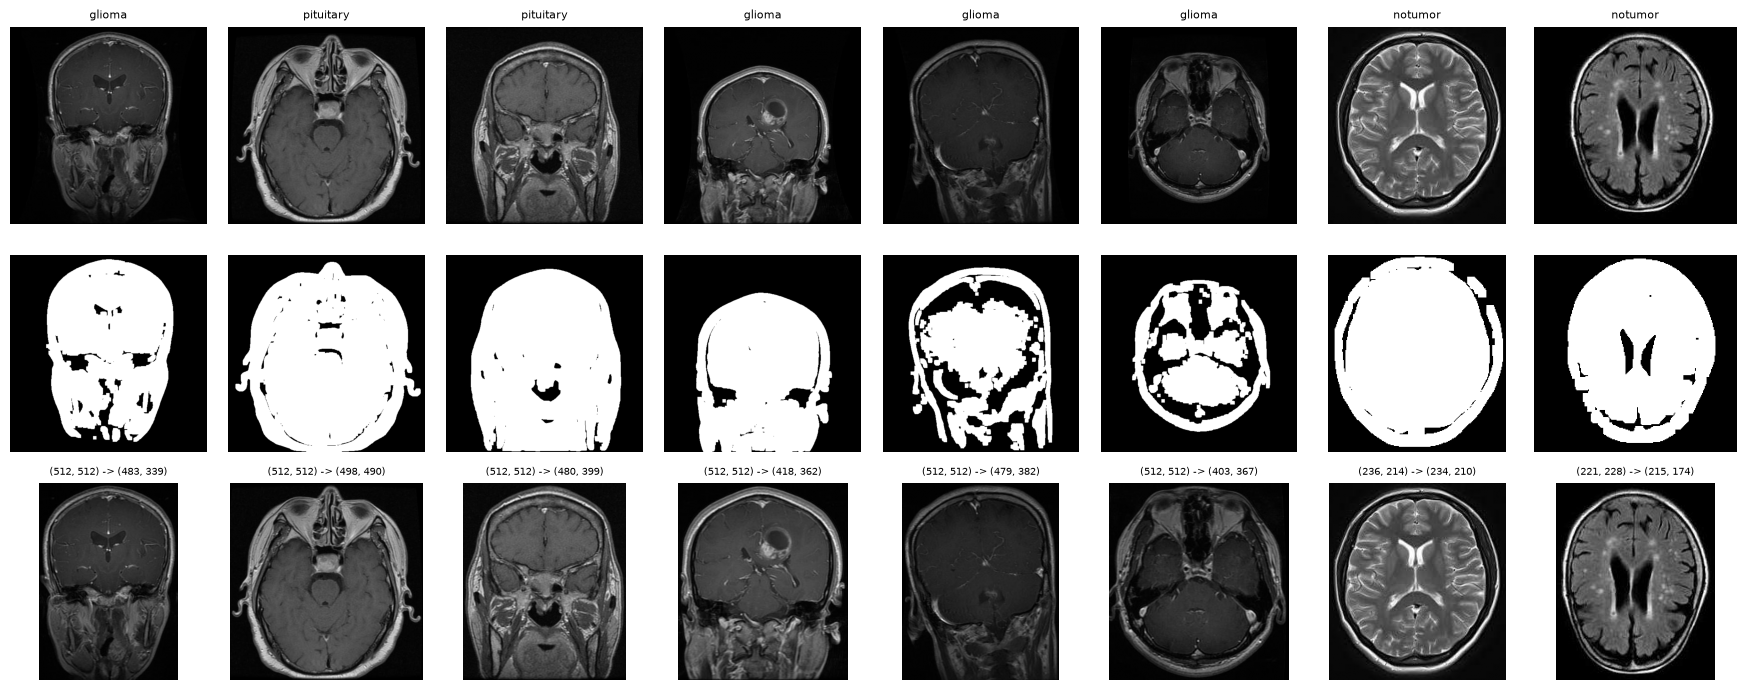

In [33]:
samples = random.sample(records, 8)

fig, axes = plt.subplots(3, len(samples), figsize=(2.2*len(samples), 7))
for j, (split, cls, p) in enumerate(samples):
    g = np.array(Image.open(p).convert("L"))
    cropped, mask = crop_margins(g, debug=True)

    axes[0, j].imshow(g, cmap="gray");       axes[0, j].set_title(cls, fontsize=8)
    axes[1, j].imshow(mask, cmap="gray")
    axes[2, j].imshow(cropped, cmap="gray")
    axes[2, j].set_title(f"{g.shape} -> {cropped.shape}", fontsize=7)
    for r in range(3):
        axes[r, j].axis("off")

axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("mask")
axes[2, 0].set_ylabel("cropped")
plt.tight_layout(); plt.show()

In [36]:
# Count how often the intensity guard fires. Non-zero means those images were returned uncropped 
failed = 0
for split, cls, p in random.sample(records, 400):
    g = np.array(Image.open(p).convert("L"))
    if crop_margins(g).shape == g.shape:
        failed += 1
print(f"Uncropped (guard fired or already tight): {failed}/400")

Uncropped (guard fired or already tight): 16/400


## 4. Pad to square, then resize

~20% of images are non-square. Stretching distorts anatomy and lets the model
learn aspect ratio as a shortcut. Padding preserves proportions at the cost of
some black border — which the crop already minimised.

In [37]:
IMG_SIZE = 224   # matches what ImageNet-pretrained backbones expect

def pad_to_square(img, fill=0):
    """Pad the shorter side symmetrically so the result is square."""
    h, w = img.shape
    if h == w:
        return img
    size = max(h, w)
    top = (size - h) // 2
    left = (size - w) // 2
    out = np.full((size, size), fill, dtype=img.dtype)
    out[top:top+h, left:left+w] = img
    return out


def preprocess(path, size=IMG_SIZE):
    """Full pipeline for one image: load -> gray -> crop -> pad -> resize."""
    g = np.array(Image.open(path).convert("L"))   # handles RGB/RGBA/L uniformly
    g = crop_margins(g)
    g = pad_to_square(g)
    # INTER_AREA is the right interpolation for downsampling — it averages
    # over the source region instead of point-sampling, avoiding aliasing.
    return cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)

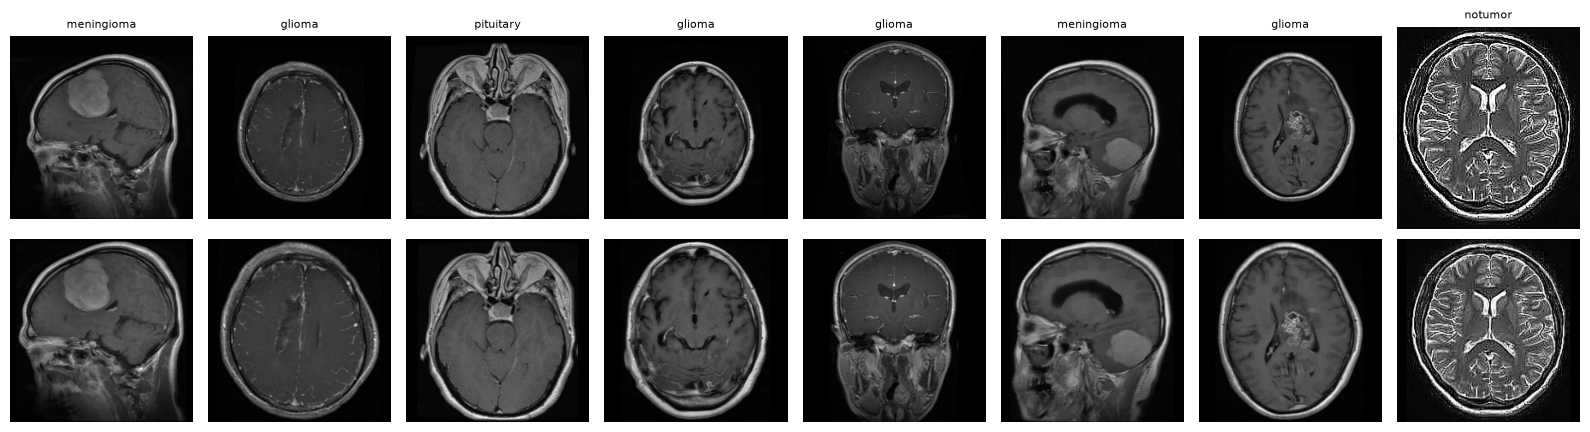

In [41]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for j, (split, cls, p) in enumerate(random.sample(records, 8)):
    axes[0, j].imshow(np.array(Image.open(p).convert("L")), cmap="gray")
    axes[0, j].set_title(cls, fontsize=8)
    axes[1, j].imshow(preprocess(p), cmap="gray")
    for r in range(2):
        axes[r, j].axis("off")
plt.tight_layout(); plt.show()

## 5. Cache to disk

Cropping is slow. Running it once and reusing the result is better. Written under `data/`, which is gitignored.

In [42]:
OUT = Path("data/processed")
cache = {}

for i, (split, cls, p) in enumerate(records):
    arr = preprocess(p)
    d = OUT / split / cls
    d.mkdir(parents=True, exist_ok=True)
    np.save(d / f"{p.stem}.npy", arr)
    cache[p] = d / f"{p.stem}.npy"
    if (i + 1) % 1000 == 0:
        print(f"  {i+1} / {len(records)}")

print(f"Cached {len(cache)} images to {OUT.resolve()}")

  1000 / 7200
  2000 / 7200
  3000 / 7200
  4000 / 7200
  5000 / 7200
  6000 / 7200
  7000 / 7200
Cached 7200 images to /Users/sanaataneja/Desktop/Summer/tumor-identification-project/notebooks/data/processed


## 6. Normalization statistics

Computed from the **training split only**. Using the full dataset leaks test
statistics into training.

If we fine-tune an ImageNet-pretrained backbone, we should use ImageNet's mean/std
instead because mismatched normalization will ruin transfer learning.

In [43]:
train_arrs = [np.load(cache[p]) for s, c, p in records if s == "Training"]
stack = np.stack(train_arrs).astype(np.float32) / 255.0

MEAN, STD = float(stack.mean()), float(stack.std())
print(f"train mean: {MEAN:.4f}")
print(f"train std : {STD:.4f}")

with open("data/norm_stats.json", "w") as f:
    json.dump({"mean": MEAN, "std": STD, "size": IMG_SIZE}, f)

# Per-class means: if notumor sits far from the others, the pulse-sequence difference is still present after cropping (expected). 
# Pulse-sequence difference means that the notumor images are not similar to the other two classes.
for cls in CLASSES:
    a = np.stack([np.load(cache[p]) for s, c, p in records
                  if s == "Training" and c == cls][:300]).astype(np.float32) / 255
    print(f"  {cls:<14} mean {a.mean():.4f}   std {a.std():.4f}")

train mean: 0.2115
train std : 0.1994
  glioma         mean 0.1700   std 0.1568
  meningioma     mean 0.2169   std 0.1939
  notumor        mean 0.2487   std 0.2539
  pituitary      mean 0.2060   std 0.1639


## 7. Leakage fixed?

Re-running the two controls from notebook 01 on the **cropped** images. This is the
measurement that indicates whether margin removal was successful.

Expected: the border test collapses toward 0.262 (the background pixels are
gone). The 8×8 test stays elevated, because the `notumor` sequence difference
lives inside the brain and cropping cannot touch it.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sub = random.sample(records, 2000)

# 8x8 test on cropped images
X8 = [cv2.resize(np.load(cache[p]), (8, 8),
                 interpolation=cv2.INTER_AREA).ravel() / 255.0
      for s, c, p in sub]
y = [c for s, c, p in sub]

Xtr, Xte, ytr, yte = train_test_split(X8, y, test_size=0.25,
                                      stratify=y, random_state=42)
acc8 = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

# Border-only test on cropped images
Xb = []
for s, c, p in sub:
    a = cv2.resize(np.load(cache[p]), (32, 32),
                   interpolation=cv2.INTER_AREA) / 255.0
    Xb.append(np.concatenate([a[:3].ravel(), a[-3:].ravel(),
                              a[3:-3, :3].ravel(), a[3:-3, -3:].ravel()]))

Xtr, Xte, ytr, yte = train_test_split(Xb, y, test_size=0.25,
                                      stratify=y, random_state=42)
accb = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

print(f"{'control':<28}{'before':>10}{'after':>10}")
print("-" * 48)
print(f"{'majority baseline':<28}{0.262:>10.3f}{0.262:>10.3f}")
print(f"{'8x8, no anatomy visible':<28}{0.650:>10.3f}{acc8:>10.3f}")
print(f"{'border pixels only':<28}{0.634:>10.3f}{accb:>10.3f}")

control                         before     after
------------------------------------------------
majority baseline                0.262     0.262
8x8, no anatomy visible          0.650     0.642
border pixels only               0.634     0.614


**The cropping wasn't very effective, it only reduced the border-pixel-only test by 0.03. This indicates that this is a limitation of the artifacts in the structure of the dataset.**

In [ ]:
# Is it pure shape? Binarize so all intensity information is destroyed: only the head silhouette survives.
Xs = []
for s, c, p in sub:
    a = cv2.resize(np.load(cache[p]), (32, 32), interpolation=cv2.INTER_AREA)
    a = (a > 25).astype(np.float32)          # silhouette only
    Xs.append(np.concatenate([a[:3].ravel(), a[-3:].ravel(),
                              a[3:-3, :3].ravel(), a[3:-3, -3:].ravel()]))
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, stratify=y, random_state=42)
print(f"silhouette-only border: {LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte):.3f}")

silhouette-only border: 0.580


In [ ]:
# Is it aspect ratio alone? Two features per image.
Xa = []
for s, c, p in sub:
    g = np.array(Image.open(p).convert("L"))
    cr = crop_margins(g)
    Xa.append([cr.shape[0] / cr.shape[1], cr.size / g.size])
Xtr, Xte, ytr, yte = train_test_split(Xa, y, test_size=0.25, stratify=y, random_state=42)
print(f"aspect ratio + area only: {LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte):.3f}")

aspect ratio + area only: 0.438


In [47]:
# Do the shortcuts survive when we drop to the subsets we actually plan to evaluate on?
#
# Testing with tumor types only and meningioma vs glioma subsets 
# If those subsets sit near their own baselines, the shortcuts don't transfer and a CNN result can be read as anatomy rather than artifact.
#
# Requires from earlier cells:
#   sub - the 2000 sampled (split, class, path) records
#   y   - class labels for sub, in the same order
#   Xa  - [aspect ratio, area fraction] per image (2 features)
#   Xs  - binarized silhouette border per image (348 features, shape only)

for name, keep in [("3-class (no notumor)", [c for c in CLASSES if c != "notumor"]),
                   ("glioma vs meningioma", ["glioma", "meningioma"])]:

    # Positions in `sub` belonging to this subset. keep indices rather than
    # rebuilding features so every subset uses the exact same feature values
    # any difference in accuracy is due to the subset, not recomputation.
    idx = [i for i, (s, c, p) in enumerate(sub) if c in keep]
    yk = [y[i] for i in idx]

    # Each subset has its own majority baseline: ~0.33 for three balanced
    # classes, ~0.50 for two. Comparing against the 4-class 0.262 would
    # overstate how much signal the features carry.
    base = max(np.bincount(np.unique(yk, return_inverse=True)[1])) / len(yk)

    for feat_name, X in [("aspect+area", Xa), ("silhouette border", Xs)]:
        Xk = [X[i] for i in idx]

        # Same split parameters as every earlier control (stratify,
        # random_state=42) so these numbers are comparable to the ones
        # already in the results table. 
        Xtr, Xte, ytr, yte = train_test_split(Xk, yk, test_size=0.25,
                                              stratify=yk, random_state=42)
        acc = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

        print(f"{name:<22} {feat_name:<20} {acc:.3f}  (baseline {base:.3f})")

# Reading the output:
#   near baseline  -> shortcut does not transfer; that evaluation is clean
#   well above     -> the subset carries its own framing confound, and a CNN
#                     result there needs the same caveats as the 4-class one

3-class (no notumor)   aspect+area          0.537  (baseline 0.339)
3-class (no notumor)   silhouette border    0.630  (baseline 0.339)
glioma vs meningioma   aspect+area          0.601  (baseline 0.505)
glioma vs meningioma   silhouette border    0.668  (baseline 0.505)


**This indicates all four classes carry a geometric confound within the dataset. Will try to agument in training.**

## Next

`03_split.ipynb` — build the train/validation split using `GroupShuffleSplit`
with `data/train_groups.json`, so near-duplicate clusters stay on one side.